##Part A: Data Preparation

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data.csv
Saving fear_greed_index.csv to fear_greed_index.csv


In [ ]:
import pandas as pd

sentiment = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

In [ ]:
print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [ ]:
print(sentiment.isnull().sum())
print(trades.isnull().sum())

print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
0
0


In [ ]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date
print(trades[['Timestamp IST', 'date']].head())

        Timestamp IST        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02


In [ ]:
daily_pnl = trades.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
trades_per_day = trades.groupby('date').size().reset_index(name='num_trades')
avg_trade_size = trades.groupby('Account')['Size USD'].mean().reset_index()
trades['win'] = trades['Closed PnL'] > 0
win_rate = trades.groupby('Account')['win'].mean().reset_index()
long_short_ratio = trades['Side'].value_counts(normalize=True)
print(long_short_ratio)
if 'leverage' in trades.columns:
    print(trades['leverage'].describe())

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


In [ ]:
merged = pd.merge(trades, sentiment, on='date', how='left')
print(merged.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  5201

## Overview of Part A: Data Preparation

In this section, we prepare the datasets for analysis. This includes loading the data, checking for missing values and duplicates, and converting timestamps into a consistent format.

We also perform feature engineering by creating important metrics such as daily PnL, win rate, trade frequency, and position size. Finally, both datasets are merged on a common date column to enable combined analysis of trader behavior and market sentiment.

## Part B: Analysis

In [ ]:
pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].mean()
print(pnl_by_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


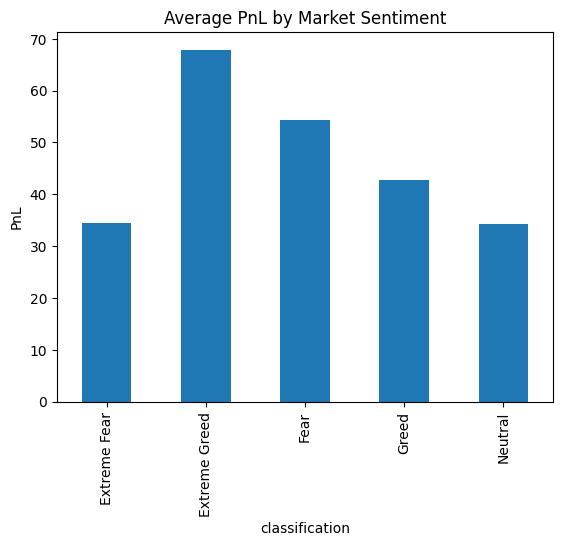

In [ ]:
import matplotlib.pyplot as plt

pnl_by_sentiment.plot(kind='bar')
plt.title("Average PnL by Market Sentiment")
plt.ylabel("PnL")
plt.show()

In [ ]:
merged['win'] = merged['Closed PnL'] > 0

win_rate_sentiment = merged.groupby('classification')['win'].mean()
print(win_rate_sentiment)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


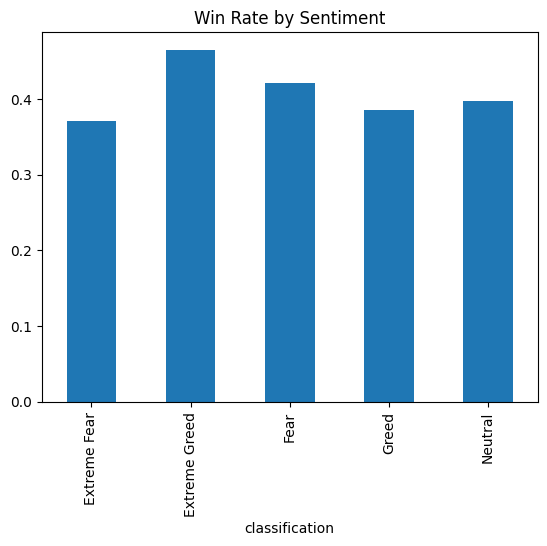

In [ ]:
win_rate_sentiment.plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.show()

In [ ]:
trades_count = merged.groupby(['date','classification']).size().reset_index(name='trades')

avg_trades = trades_count.groupby('classification')['trades'].mean()
print(avg_trades)

classification
Extreme Fear     1528.571429
Extreme Greed     350.807018
Fear              679.527473
Greed             260.637306
Neutral           562.477612
Name: trades, dtype: float64


In [ ]:
long_short = merged.groupby(['classification','Side']).size().unstack()
print(long_short)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


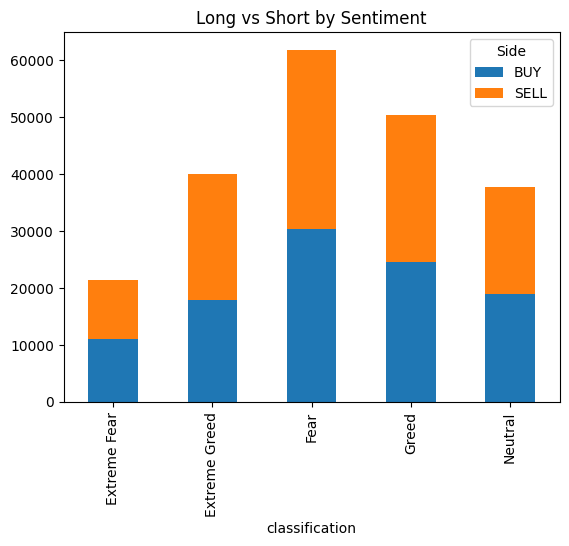

In [ ]:
long_short.plot(kind='bar', stacked=True)
plt.title("Long vs Short by Sentiment")
plt.show()

In [ ]:
size_by_sentiment = merged.groupby('classification')['Size USD'].mean()
print(size_by_sentiment)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


In [ ]:
if 'leverage' in merged.columns:
    leverage_sentiment = merged.groupby('classification')['leverage'].mean()
    print(leverage_sentiment)

In [25]:
trade_counts = merged['Account'].value_counts()

frequent_traders = trade_counts[trade_counts > trade_counts.median()].index

merged['trader_type'] = merged['Account'].apply(
    lambda x: 'Frequent' if x in frequent_traders else 'Infrequent'
)

In [26]:
account_pnl = merged.groupby('Account')['Closed PnL'].sum()

merged['profit_type'] = merged['Account'].apply(
    lambda x: 'Winner' if account_pnl[x] > 0 else 'Loser'
)

In [28]:
segment_analysis = merged.groupby(['classification'])['Closed PnL'].mean()
print(segment_analysis)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


## Overview of Part B: Analysis

In this section, we analyze how market sentiment (Fear vs Greed) affects trader performance and behavior.

We compare key metrics such as PnL and win rate across different sentiment conditions. Additionally, we examine behavioral changes like trade frequency, position size, and long/short preferences.

We also segment traders into different groups (e.g., frequent vs infrequent, high vs low trade size) to gain deeper insights into how different types of traders respond to market sentiment.

## Part C: Actionable Strategies

In this section, we translate our analysis into practical strategies that traders can apply in real-world scenarios. These strategies are based on observed patterns in trader performance and behavior under different market sentiment conditions.

#### Strategy 1: Dynamic Risk Adjustment

Traders should adjust their position sizes based on market sentiment. During Fear periods, reducing position sizes can help minimize potential losses due to high uncertainty and volatility. During Greed phases, traders can cautiously increase exposure to take advantage of bullish trends. This strategy helps in managing risk effectively while maximizing returns in favorable market conditions.

#### Strategy 2: Trade Frequency Optimization

Trading frequency should be aligned with market sentiment. During Fear periods, reducing the number of trades can prevent overtrading and unnecessary losses. In contrast, during Greed phases, increasing trade participation may improve profitability. This approach ensures disciplined trading and avoids emotional decision-making.

#### Strategy 3: Position Bias Based on Sentiment

Traders can align their position types with market sentiment. During Greed phases, taking long positions is generally more profitable due to upward market trends. During Fear phases, adopting short or defensive strategies can help mitigate losses. This strategy aligns trading direction with overall market behavior.

## Conclusion

This analysis demonstrates that market sentiment plays a significant role in influencing trader behavior and performance. Traders tend to take more risks and achieve higher profitability during Greed phases, while becoming more cautious during Fear periods. By adapting strategies based on sentiment, traders can improve decision-making, manage risks effectively, and enhance overall performance.